## Map-to-Prediciton 

This book takes in a calibrated water elevation map for a specific site and a set of test images and predicits the water in each image in (ft). 

In [2]:
import os
import glob
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import cm
from PIL import Image
import cv2
import torch
import json


## Existing Sites

Runs with an existing `run_config.json`:

In [3]:
site_list = sorted(glob.glob('cameras/*/*/run_config.json'))
for i, cfg in enumerate(site_list):
    parts = cfg.split(os.sep)
    print(f"Site {i}: '{parts[1]}'")
    print(f"test_run_name = '{parts[2]}'")
    print()

Site 0: 'CA_Arroyo_DE_LA_Laguna_A_Corte_Madrid_nr_Pleasanton'
test_run_name = 'event_2026-02-15'

Site 1: 'CA_Arroyo_DE_LA_Laguna_A_Corte_Madrid_nr_Pleasanton'
test_run_name = 'test_2025-12-24'

Site 2: 'OK_Illinois_River_near_Moodys'
test_run_name = 'event_2026-03-04'

Site 3: 'OK_Illinois_River_near_Moodys'
test_run_name = 'test_2026-04-03'

Site 4: 'SC_Waccamaw_River_at_SC_22_below_Longs'
test_run_name = 'event_2025-08-14'

Site 5: 'VA_DIFFICULT_RUN_ABOVE_FOX_LAKE_NEAR_FAIRFAX'
test_run_name = 'event_2026-03-16'

Site 6: 'WI_East_Branch_Pecatonica_River_near_Blanchardville_Bullet'
test_run_name = 'event_2025-06-23'

Site 7: 'WI_East_Branch_Pecatonica_River_near_Blanchardville_Bullet'
test_run_name = 'test_2025-03-25'



## Configuration

Use site_selection to select the folder/setup to draw the elevation and depth maps from for prediciton. Use test_run_name to specify a folder containing the images, masks, and csv you want to predict the water elevations for.

In [4]:
# Select site and test dierctory. The test data will be drawn from the specified folder for the camera

##### Input ####
site_selection = 5
test_run_name = 'event_2026-03-16'
# test_run_name = 'event_2025-08-14'
# test_run_name = 'test_2025-03-25'
# test_run_name = 'event_2025-06-23'
# test_run_name = 'event_2026-02-15'
# test_run_name = 'test_2025-12-24'
# test_run_name = 'event_2026-03-04'
# test_run_name = 'test_2026-04-03'

################

cfg_path = site_list[site_selection]

if os.path.exists(cfg_path):
    with open(cfg_path) as f:
        cfg = json.load(f)

camera_id = cfg.get('camera_id')
run_name  = cfg.get('run_name')
run_dir = f'cameras/{camera_id}/{run_name}'

evel_path = f'{run_dir}/depth/calibrated_elevation.npy'
depth_path = f'{run_dir}/depth/relative_depth.npy'

print(f'Using elevation map from: {evel_path}')

test_dir = f'cameras/{camera_id}/{test_run_name}'

images_dir = f'{test_dir}/images'
masks_dir = f'{test_dir}/masks'
csv_path = f'{test_dir}/images_and_data.csv'

# # Output directory
output_dir = f'{test_dir}/predicitons'
os.makedirs(output_dir, exist_ok=True)

print(f"Loading data from: {csv_path}")
print(f"Output will be saved to: {output_dir}")

Using elevation map from: cameras/VA_DIFFICULT_RUN_ABOVE_FOX_LAKE_NEAR_FAIRFAX/event_2026-03-16/depth/calibrated_elevation.npy
Loading data from: cameras/VA_DIFFICULT_RUN_ABOVE_FOX_LAKE_NEAR_FAIRFAX/event_2026-03-16/images_and_data.csv
Output will be saved to: cameras/VA_DIFFICULT_RUN_ABOVE_FOX_LAKE_NEAR_FAIRFAX/event_2026-03-16/predicitons


## Load Elevation Map and Data


Found 42 masks marked as 'bad' - excluding from analysis
Excluded indices: [23, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87]
Remaining records after filtering: 46
Loaded 46 records

Columns: ['Unnamed: 0', 'image_times', 'image_names', 'data_times', 'site_no', '00010', '00010_cd', '00060', '00060_cd', '00065', '00065_cd', '00095', '00095_cd', '00300', '00300_cd', '00400', '00400_cd', '63680_ysi exo', '63680_ysi exo_cd', '99234', '99234_cd', 'time_diff_sec', 'mask_filename', 'quality_flag']

First few rows:


,image_names,mask_filename
0,VA_DIFFICULT_RUN_ABOVE_FOX_LAKE_NEAR_FAIRFAX__...,00000_obj1.npy
1,VA_DIFFICULT_RUN_ABOVE_FOX_LAKE_NEAR_FAIRFAX__...,00001_obj1.npy
2,VA_DIFFICULT_RUN_ABOVE_FOX_LAKE_NEAR_FAIRFAX__...,00002_obj1.npy
3,VA_DIFFICULT_RUN_ABOVE_FOX_LAKE_NEAR_FAIRFAX__...,00003_obj1.npy
4,VA_DIFFICULT_RUN_ABOVE_FOX_LAKE_NEAR_FAIRFAX__...,00004_obj1.npy


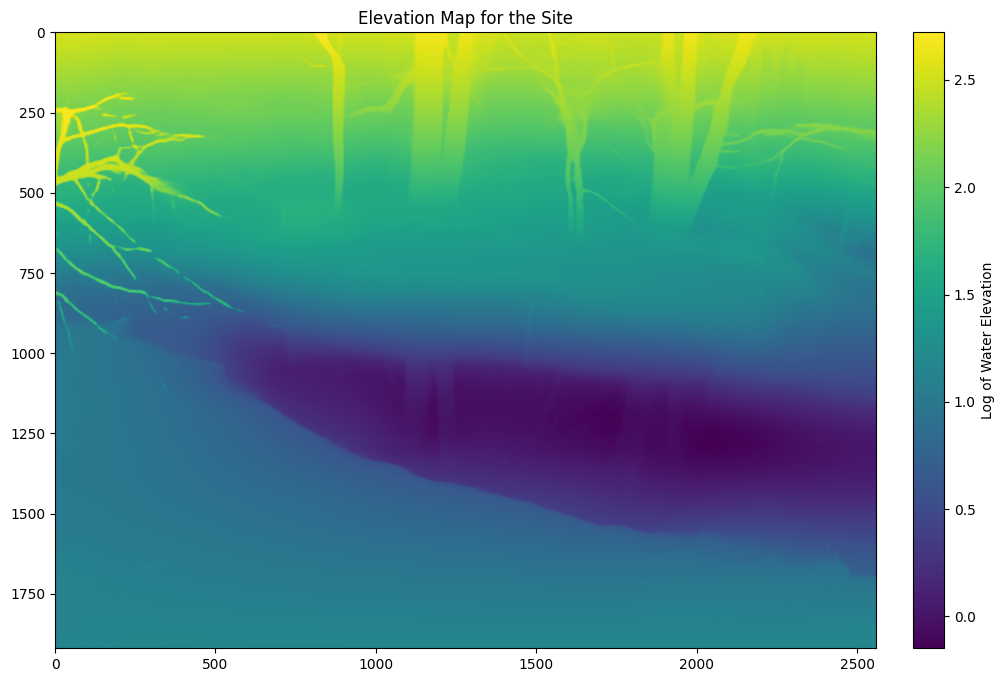

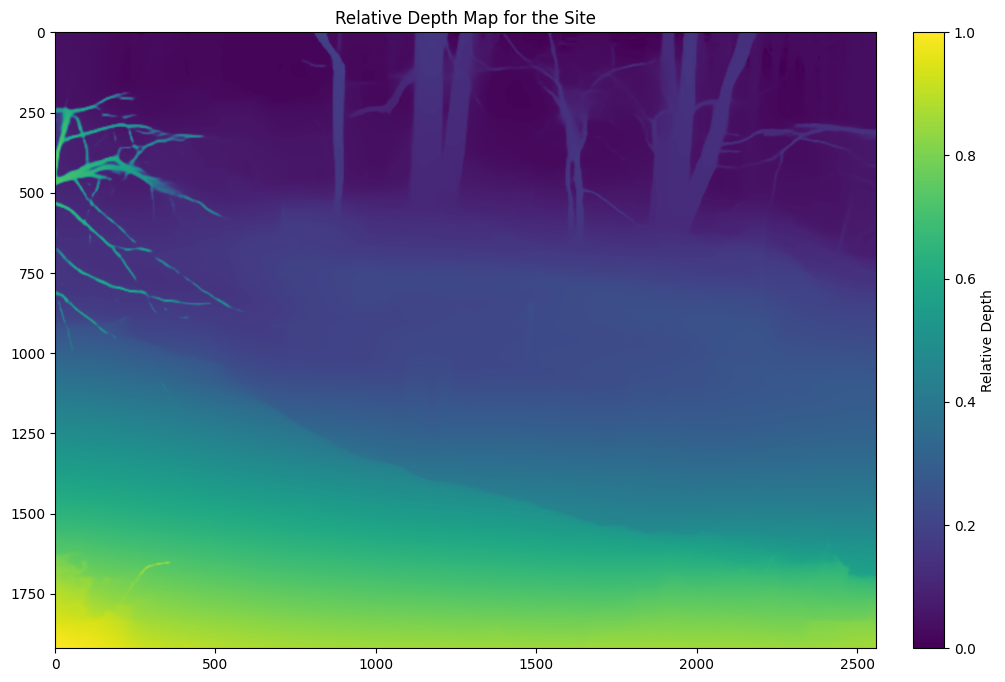

In [5]:
elevation_map = np.load(evel_path)

# gradient_image = np.abs(cv2.Sobel(elevation_map, cv2.CV_64F, 1, 1, ksize=7))

rel_depth_map = np.load(depth_path)
# Rescale relative depth map to be from 0-1 with 1 being closest 
rel_depth_map = (rel_depth_map - np.min(rel_depth_map))/(np.max(rel_depth_map)-np.min(rel_depth_map))

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(np.log(elevation_map))
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Log of Water Elevation')
plt.title("Elevation Map for the Site")

# fig, ax = plt.subplots(figsize=(12, 8))
# im = ax.imshow(gradient_image, vmax=2)
# plt.colorbar(im, ax=ax, fraction=0.06, pad=0.04, label='Gradient of Water Elevation')
# plt.title("Gradient of Water Elevation Map for the Site")

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(rel_depth_map)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Relative Depth')
plt.title("Relative Depth Map for the Site")

# Load the CSV with images, masks, and gage height data
df = pd.read_csv(csv_path)

# Filter out bad quality masks if quality_flag column exists
if 'quality_flag' in df.columns:
    n_bad = (df['quality_flag'] == 'bad').sum()
    if n_bad > 0:
        print(f"\nFound {n_bad} masks marked as 'bad' - excluding from analysis")
        bad_indices = df[df['quality_flag'] == 'bad'].index.tolist()
        print(f"Excluded indices: {bad_indices}")
        df = df[df['quality_flag'] != 'bad'].reset_index(drop=True)
        print(f"Remaining records after filtering: {len(df)}")
    else:
        print(f"\nAll masks marked as 'good' - no filtering applied")
else:
    print(f"\nNo quality_flag column found - using all masks")
    print(f"(Run notebook 02.5 to review and flag bad masks)")


print(f"Loaded {len(df)} records")

print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
display(df[['image_names', 'mask_filename']].head())


## Functions For Elevation Prediction

In [27]:
import weightedstats as ws 

def load_mask(mask_path):
    """
    Load a mask from a .npy file.
    
    Args:
        mask_path: Path to .npy mask file
    
    Returns:
        Binary mask array
    """
    mask = np.load(mask_path)
    if mask.ndim == 3:
        mask = mask.squeeze()
    return mask.astype(bool)


def predict_elevation(elevation_map, rel_depth_map, water_mask, prediction_method="weighted_median", return_verbose = False, dialations=1):
    """
    Predicts the water eleveation from an image and elevation map using median 
    
    Args:
        elevation_map: Map of water elevations for the site
        rel_depth_map: Map of relative scene depths 
        water_mask: Mask of the water 
        prediction_method: Method used to predict the water level [weighted_median, median, mean, mode]
        return_verbose: If true, returns predicted_elevations, elevation_vals, edges, elevation_st_devs, water_mask_new [True/False]
        dialations: Number of dialations to apply to the edges. Effectively specifies the line thickness 
    Returns:
        predicted_elevation: Predicted water elevation
        elevation_vals: The full list of elevations  
        edges: The edge masks  
        elevation_st_devs: The standard deviations for each edge 
        water_mask_new: The cleaned water mask
    """
    if np.all(water_mask ==0):
        print("Error: Empty Mask Supplied")
        return np.nan
    
    # Find edge by subtracting the erroded image
    kernel = np.ones((3,3), np.uint8)

    # First make sure mask is continuous peice 
    initial_dialations = 30
    water_mask_new = cv2.dilate(water_mask.astype(np.uint8), kernel, iterations=initial_dialations)
    water_mask_new = cv2.erode(water_mask_new, kernel, iterations=initial_dialations)

    # Then make sure mask is relatively smooth, removing crazy abnormalities
    water_mask_new = cv2.erode(water_mask_new, kernel, iterations=initial_dialations)
    water_mask_new = cv2.dilate(water_mask_new, kernel, iterations=initial_dialations)

    # Then find edge of water mask 
    erosion = cv2.erode(water_mask_new, kernel, iterations=1)
    edges = cv2.subtract(water_mask_new, erosion)
    
    # Dialate to increase the edge size 
    if dialations >0:
        edges = cv2.dilate(edges.astype(np.uint8), kernel, iterations=dialations)

    # Calculate the the sizes of all edge peices and remove if much shorter than longest edge 
    _, labels, stats, _ = cv2.connectedComponentsWithStats(edges, connectivity=4)
    areas = stats[:, cv2.CC_STAT_AREA]

    sorted_areas = np.sort(areas)[::-1]
  
    # Find all edges that have an area of at least 40% of the largest non backgorund area 
    valid_labels = np.argwhere(areas> sorted_areas[1]*.4)
    # Remove backgound label 
    valid_labels = valid_labels[valid_labels != 0]

    # Update edges to only use valid edges, keep each shoreline seperate 
    edges = np.zeros((len(valid_labels), edges.shape[0], edges.shape[1]),dtype=bool)
    for i, label in enumerate(valid_labels):
        edges[i] = labels == label 

    elevation_vals = []
    elevation_st_devs = []
    depth_info = []

    # Get elevation and depth pixels for each water edge
    for i in range(len(valid_labels)):
        elevation_vals.append(elevation_map[edges[i]])
        elevation_st_devs.append(np.std(elevation_map[edges[i]]))

        # Get depth info to weight pixels closer to the camera
        depth_info.append(rel_depth_map[edges[i]])
    
    predicted_elevations = []
    
    # Make a predicition for each edge/shore line
    for i in range(len(valid_labels)):
        if prediction_method == "weighted_median":
            predicted_elevations.append(ws.weighted_median(elevation_vals[i], weights= depth_info[i]**2))

        elif prediction_method == "median":
            predicted_elevations.append(np.median(elevation_vals[i]))

        elif prediction_method == "mean":
            predicted_elevations.append(np.mean(elevation_vals[i]))

        elif prediction_method == "mode":
            counts, bin_edges = np.histogram(elevation_vals[i])
            mode_pred_idx = np.argmax(counts)
            predicted_elevations.append(np.mean((bin_edges[mode_pred_idx],bin_edges[mode_pred_idx+1])))
        
        else: 
            raise ValueError("Invalid prediction method specified")

    # predicted_elevations = np.array(predicted_elevations)
    pred_weights = 1/(np.array(elevation_st_devs)**2)

    final_prediction = np.sum(predicted_elevations*(pred_weights/np.sum(pred_weights)))

    if return_verbose == True:
        return final_prediction, predicted_elevations, elevation_vals, edges, elevation_st_devs, water_mask_new

    return [final_prediction]

def get_specific_est_info(index, elevation_map, rel_depth_map, images_df, images_dir, masks_dir, prediction_method= "weighted_median", line_thickness=1):
    image_info = images_df.iloc[index]

    # Ground values 
    true_water_elevations = images_df['00065']
    true_val = true_water_elevations[index]   

    # Load Image
    image_path = os.path.join(images_dir, image_info['image_names'])
    water_image = cv2.cvtColor(cv2.imread(image_path), code=cv2.COLOR_BGR2RGB)

    # Load Mask
    mask_path = os.path.join(masks_dir, image_info['mask_filename'])
    water_mask = load_mask(mask_path)

    # Predict Water Level
    final_predicted, predicted_all, pred_vals_all, edges_all, all_pred_stds, water_mask_new = predict_elevation(elevation_map, rel_depth_map, water_mask, prediction_method= prediction_method, return_verbose=True, dialations=line_thickness)
    
    # Print Information about the frame
    print(f"Final Prediciton for Index {index}: {final_predicted}, True: {true_val}")
    print(f"Test Data Range: {np.min(true_water_elevations)}-{np.max(true_water_elevations)}ft.")
    print(f"Map Range: {np.min(elevation_map)}-{np.max(elevation_map)}ft.")

    combined_edge = np.zeros_like(edges_all[0])

    for i, (predicted, pred_vals, pred_std, edges) in enumerate(zip(predicted_all, pred_vals_all, all_pred_stds, edges_all)):
        
        combined_edge = np.logical_or(combined_edge, edges)

        min_predicted = np.min(pred_vals)
        max_predicted = np.max(pred_vals)

        mean_pred = np.mean(pred_vals)

        counts, bin_edges = np.histogram(pred_vals)
        mode_pred_idx = np.argmax(counts)
        mode_pred = np.mean((bin_edges[mode_pred_idx],bin_edges[mode_pred_idx+1]))

        # Plot Edge Used for Prediction
        plt.figure()
        plt.imshow(edges*elevation_map, vmin=min_predicted, vmax=max_predicted)
        plt.title(f"Edge Elevations {i} - Predicted: {predicted:.2f}, True: {true_val:.2f}")
        plt.colorbar()

        # Plot depth information along the edge
        plt.figure()
        plt.imshow(rel_depth_map*edges)
        plt.title(f"Relative Depth Info {i}")
        plt.colorbar()

        # Plot Histogram for Values used in Prediction 
        plt.figure()
        plt.hist(pred_vals)
        plt.axvline(x=predicted, color='red', linestyle='dashed', linewidth=2, label='Predicted')
        plt.axvline(x=true_val, color='blue', linestyle='dashed', linewidth=2, label='True')
        plt.axvline(x=mean_pred, color='green', linestyle='dashed', linewidth=2, label='Mean')
        plt.axvline(x=mode_pred, color='yellow', linestyle='dashed', linewidth=2, label='Mode')

        plt.title(f"Prediciton Information {i} - Predicted: {predicted:.2f}, True: {true_val:.2f}")
        plt.legend(["Predicted", "True", "Mean", "Mode"])

        plt.figure()
        plt.imshow(edges)
        plt.axis("off")
        plt.title(f"Mask Edge {i}")

        # Print Information about the frame
        print(f"Prediciton for Index {index} Line {i}: {predicted} with std {pred_std}, True: {true_val}")
    
    # Show image without water mask
    plt.figure()
    plt.imshow(water_image)
    plt.axis("off")
    plt.title("Original Image")

    # Show image with water mask
    plt.figure()
    plt.imshow(water_image)
    plt.imshow(water_mask_new, alpha=0.3)
    plt.axis("off")
    plt.title("Cleaned Water Mask")

    # Show All Edges
    plt.figure()
    plt.imshow(combined_edge)
    plt.axis("off")
    plt.title("All Edges")

def run_prediciton(elevation_map, rel_depth_map, images_df, masks_dir, prediction_method="weighted_median"):
    """
    Predicts the water eleveation for set of frames usings the specified method
    
    Args:
        elevation_map: Map of water elevations for the site
        water_mask: Mask of the water 
        prediction_method: Method used to predict the water level [weighted_median, median, mean, mode]
    Returns:
        predicted_water_elevations: Predicted water elevations
        true_water_elevations: True water elevations for the provided frames 
    """
    predicted_water_elevations = np.zeros((images_df.shape[0],1))
    for idx, row in images_df.iterrows():
        mask_path = os.path.join(masks_dir, row['mask_filename'])
        if not os.path.exists(mask_path):
            print(f"Warning: Mask not found: {mask_path}")
            continue

        mask = load_mask(mask_path)
        pred = predict_elevation(elevation_map, rel_depth_map, mask, prediction_method=prediction_method)
        # If there are more than 1 edges detected, increase the size of the output 
        if len(pred) > predicted_water_elevations.shape[1]:
            extra_columns = len(pred) - predicted_water_elevations.shape[1]
            predicted_water_elevations = np.hstack((predicted_water_elevations, np.zeros((predicted_water_elevations.shape[0], extra_columns))))
            predicted_water_elevations[idx, 0:len(pred)] = pred 
        else:
            predicted_water_elevations[idx, 0:len(pred)] = pred 

    true_water_elevations = df['00065']
    return predicted_water_elevations, true_water_elevations


## Run Prediciton For Images

Specify the method used to predict the elevation: 

MAE when using weighted median - Pred 0: 0.6042495939740553 ft


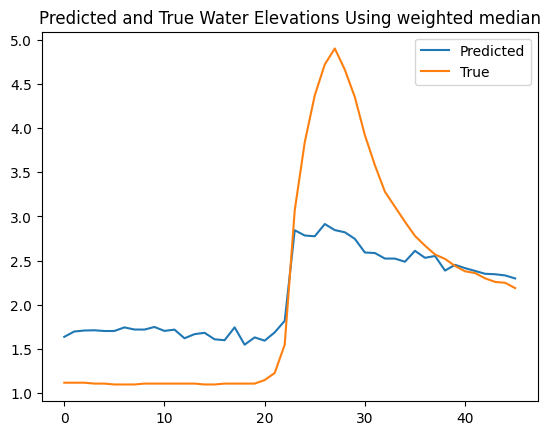

In [ ]:
methods =  ["weighted_median"]
errors = np.zeros((len(methods), df.shape[0]))
for i, method in enumerate(methods):
    pred_w_ele, true_w_ele = run_prediciton(elevation_map, rel_depth_map, df, masks_dir, method)

    plt.figure()
    plt.plot(pred_w_ele)
    plt.plot(true_w_ele)
    plt.title(f"Predicted and True Water Elevations Using {method.replace('_', ' ')}")
    # plt.legend(("Predicted", "True"))
    legend_entries = []
    for j in range(pred_w_ele.shape[1]):
        legend_entries.append(f"Predicted")
    legend_entries.append("True")
    plt.legend(legend_entries)
    plt.xlabel("Frame Index")
    plt.ylabel("Water Elevation (ft.)")

    plt.savefig(os.path.join(output_dir,f"Water Level Predicitons Using {method.replace('_', ' ')}.png"))

    # Calculate Error in Prediction
    # errors[i] = np.abs(pred_w_ele-true_w_ele)
    # mae = np.mean(errors[i])
    for j in range(pred_w_ele.shape[1]):
        pred_error = np.abs(pred_w_ele[:,j]-true_w_ele)
        if j == 0:
            errors[i] = pred_error

        mae = np.mean(pred_error)
        print(f"MAE when using {method.replace('_', ' ')} - Pred {j}: {mae} ft")


## Get Detailed Informaiton and Plots for Worst Prediction 

Final Prediciton for Index 27: 2.8457068239003505, True: 4.9
Test Data Range: 1.1-4.9ft.
Map Range: 0.8618974817678389-15.21081551513123ft.
Prediciton for Index 27 Line 0: 3.2447558113296378 with std 0.5671412885576433, True: 4.9
Prediciton for Index 27 Line 1: 2.3946348300692986 with std 0.602977477679237, True: 4.9


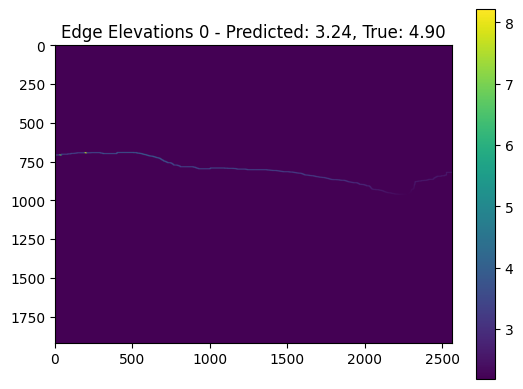

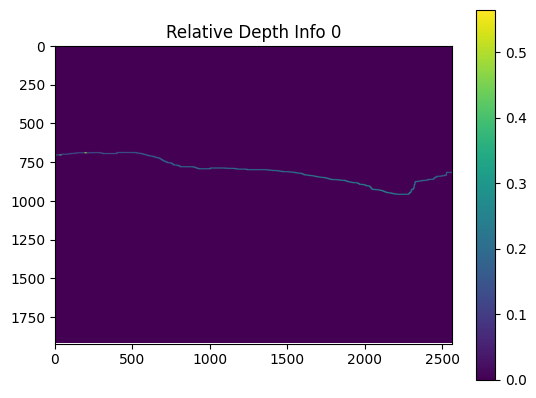

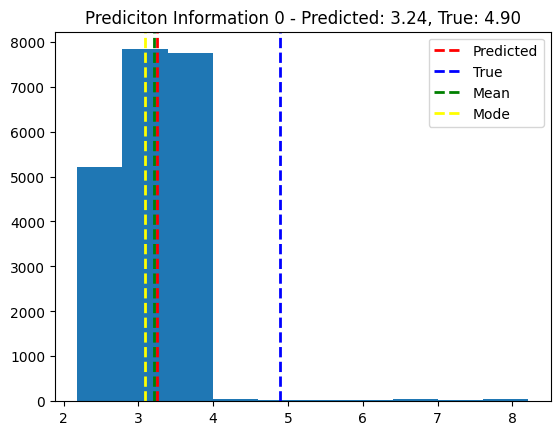

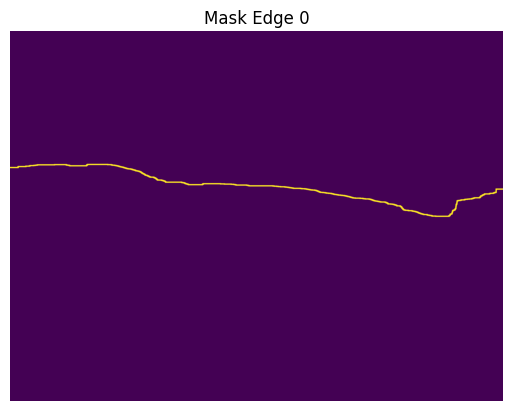

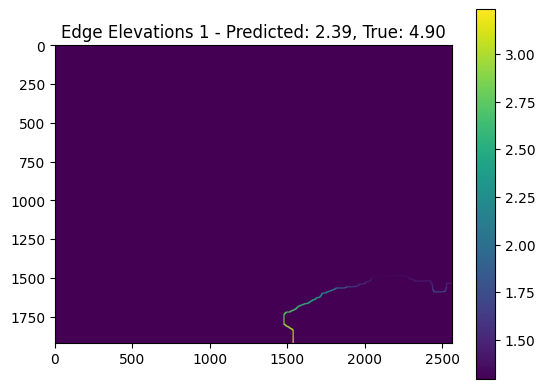

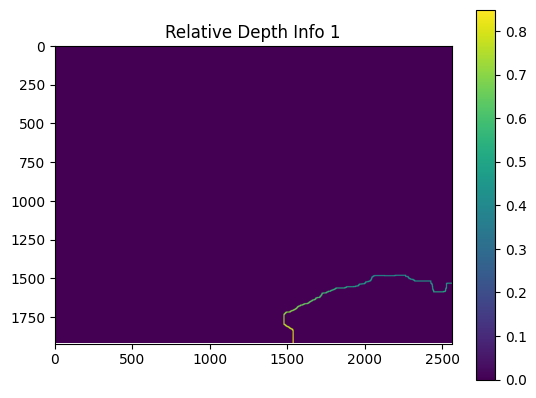

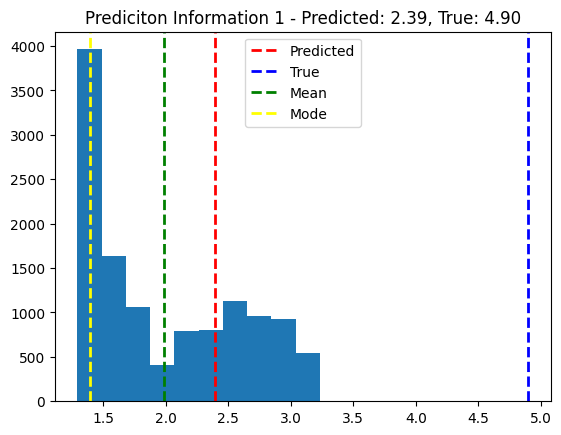

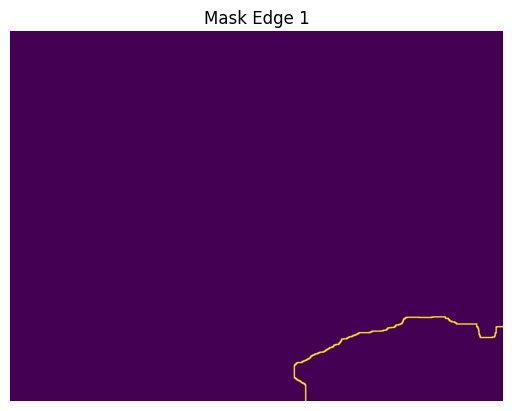

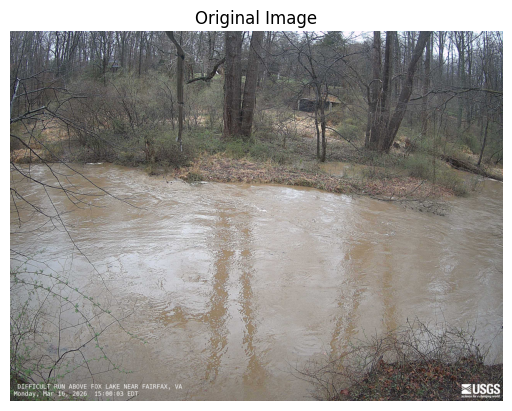

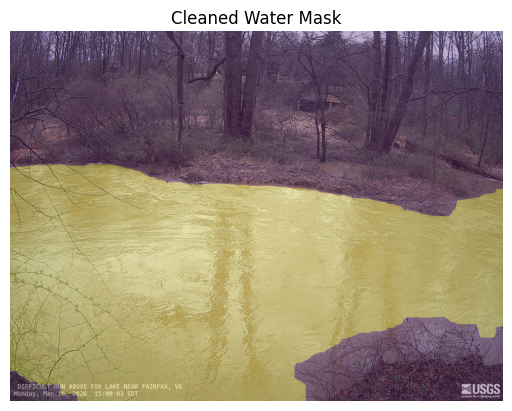

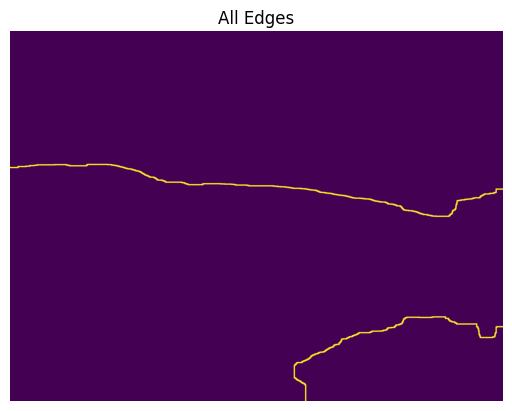

In [26]:
# Show information on the worst prediciton 
for i, method in enumerate(methods):
    worst_error_idx = np.argmax(errors[i])
    get_specific_est_info(worst_error_idx, elevation_map, rel_depth_map, df, images_dir, masks_dir, method, line_thickness=3)
    

## Get Detailed Information on a Specific Frame

Final Prediciton for Index 20: 1.5956455842263875, True: 1.15
Test Data Range: 1.1-4.9ft.
Map Range: 0.8618974817678389-15.21081551513123ft.
Prediciton for Index 20 Line 0: 1.5956455842263875 with std 0.6001062833352747, True: 1.15


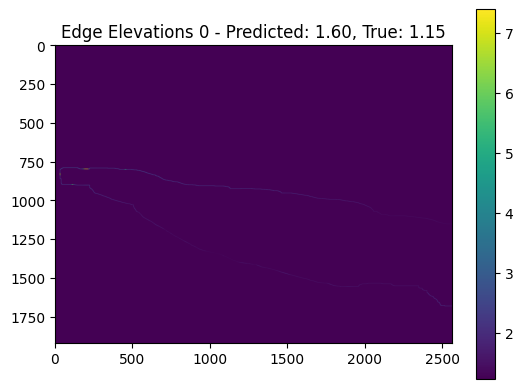

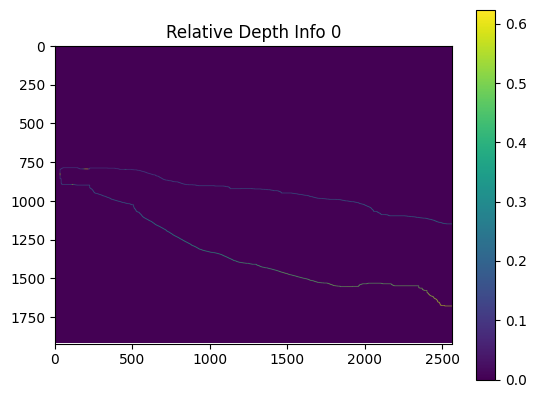

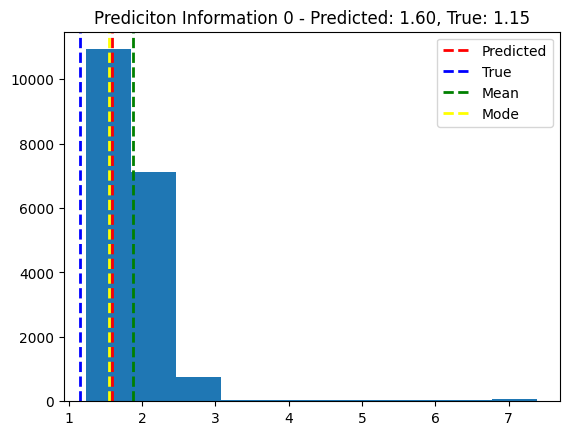

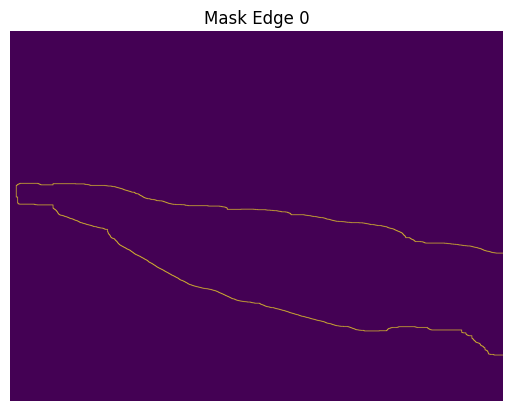

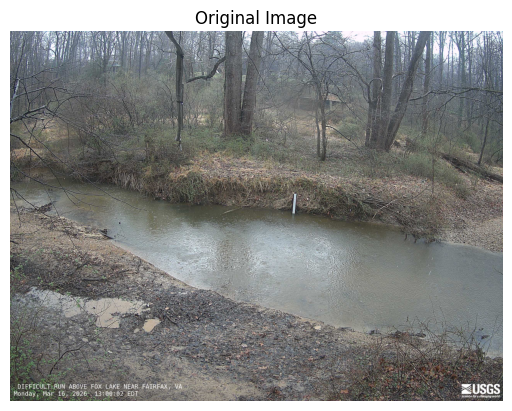

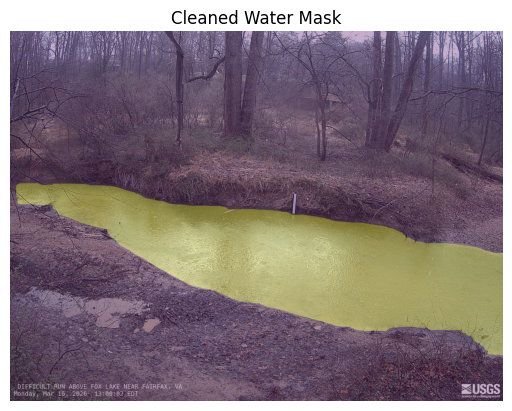

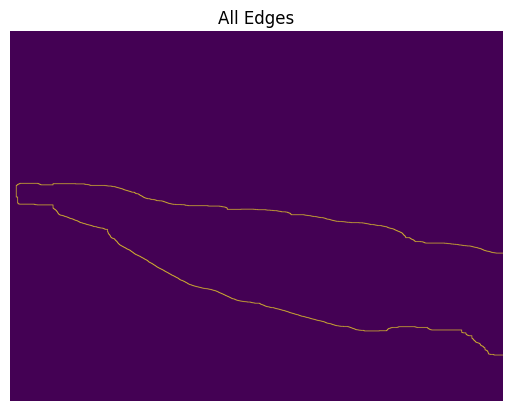

In [21]:
get_specific_est_info(20, elevation_map, rel_depth_map, df, images_dir, masks_dir, method)